# V1 sans normalisation

/global/u1/h/hugon/home/acm
X_pcf shape   : (160, 50)
X_ds shape    : (160, 400)
X_combo shape : (160, 450)
Covariance and derivatives shapes:
(50, 50) (50,)
(400, 400) (400,)
(450, 450) (450,)


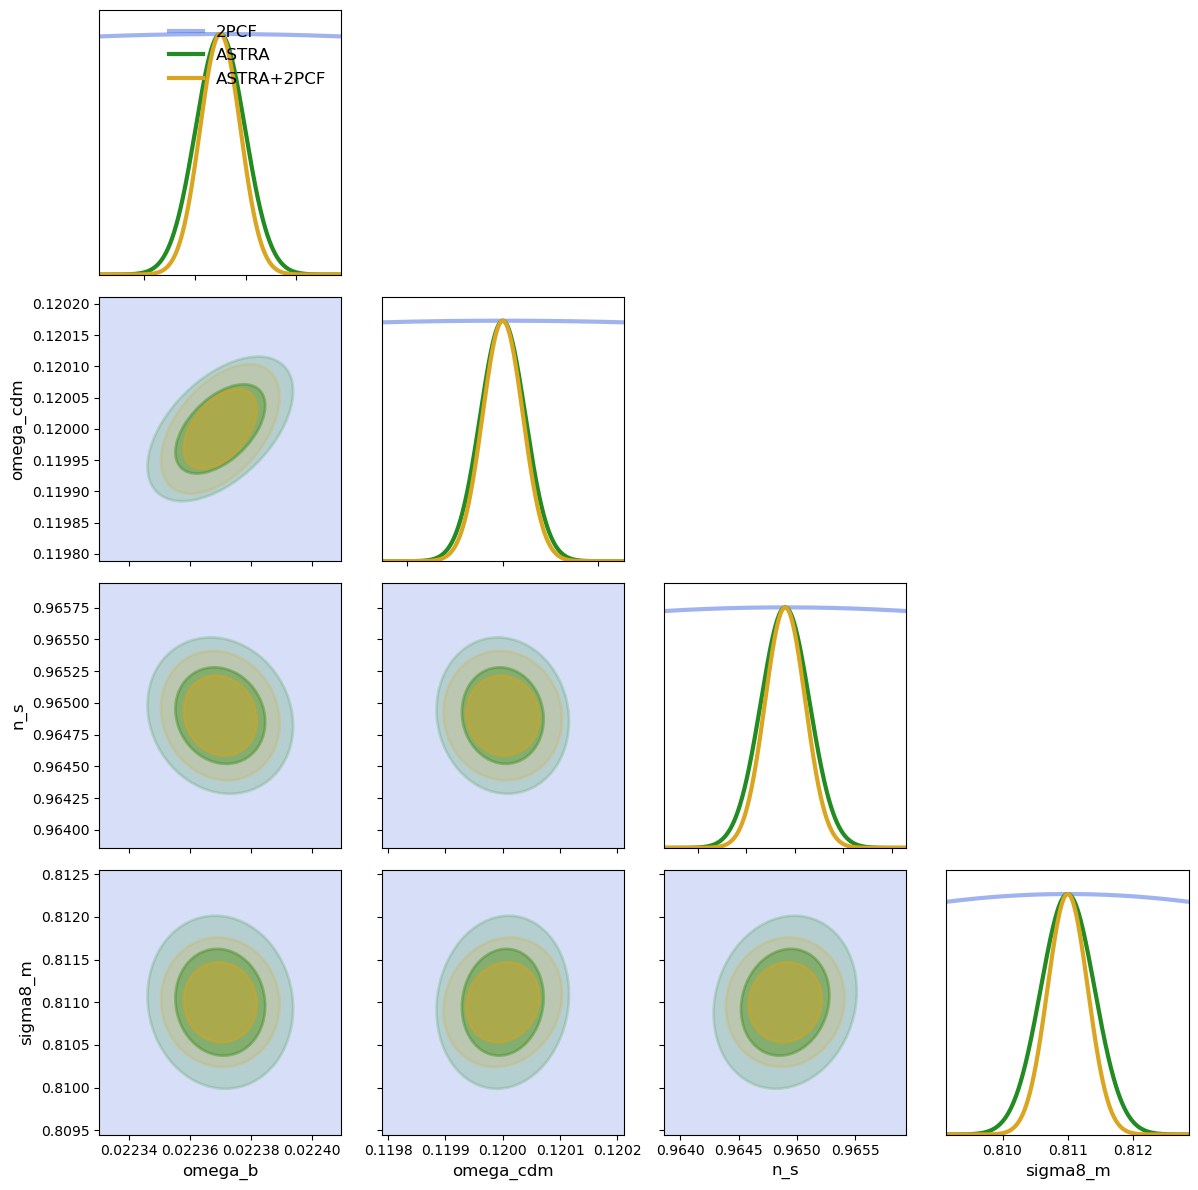

Condition numbers:
PCF   : 664.7556592658276
DS    : 2591.6534902110275
Combo : 2071.8134325233696

2PCF
omega_b 0.0003374975270235821
omega_cdm 0.0021641327532522635
n_s 0.007101671729241724
sigma8_m 0.0072500677073220905

ASTRA
omega_b 9.779612018126911e-06
omega_cdm 4.7237665466357057e-05
n_s 0.0002514011526957553
sigma8_m 0.0004141374034810227

ASTRA+2PCF
omega_b 7.970997564470505e-06
omega_cdm 4.2304577786971215e-05
n_s 0.00020829616531490756
sigma8_m 0.0003099884952025837


In [5]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats.distributions import chi2
import os
import pandas as pd
%cd /global/homes/h/hugon/home/acm

# ============================================================
# HELPERS
# ============================================================

def stack(arr):
    return np.vstack([
        np.asarray(x, dtype=float)
        for x in arr
    ])


def group_by_cosmo(data):

    grouped = {}

    for i, cid in enumerate(data["cosmo_id"]):
        grouped.setdefault(int(cid), []).append(i)

    return grouped


# ============================================================
# LOAD DATA
# ============================================================

data_cov = np.load(
    "dataset_covariance_astra_160_1_250_200.npz",
    allow_pickle=True
)

data_deriv = np.load(
    "dataset_derivatives_astra_64_1_250_200.npz",
    allow_pickle=True
)


# ============================================================
# COSMOLOGY SETUP
# ============================================================

FID_COSMO = 0

pairs = {
    "omega_b":   (100, 101),
    "omega_cdm": (102, 103),
    "n_s":       (104, 105),
    "sigma8_m":  (112, 113),
}

params = list(pairs.keys())


params = ["omega_b", "omega_cdm", "n_s", "sigma8_m"]

fiducial = {
    "omega_b":   0.02237,
    "omega_cdm": 0.1200,
    "n_s":       0.9649,
    "sigma8_m":  0.811
}

colors = {
    "2PCF": "royalblue",
    "ASTRA": "forestgreen",
    "ASTRA+2PCF": "goldenrod"
}


idx_fid = np.where(data_cov["cosmo_id"] == FID_COSMO)[0]

group_deriv = group_by_cosmo(data_deriv)

COSMOLOGY_FILE = "/global/homes/h/hugon/home/acm/nb/cosmologies.csv"
cosmo_df = pd.read_csv(COSMOLOGY_FILE)
cosmo_df.columns = cosmo_df.columns.str.strip()

cosmo_df["cosmo_id"] = (
    cosmo_df["root"]
    .str.extract(r"cosm(\d+)")
    .astype(int)
)

cosmo_df = cosmo_df.set_index("cosmo_id")


# ============================================================
# BUILD OBSERVABLES
# ============================================================

# ----------------------------
# 2PCF
# ----------------------------

X_pcf = stack(data_cov["pcf"][idx_fid])

# ----------------------------
# ASTRA / DS
# ----------------------------

X_ds = stack(data_cov["ds_z"][idx_fid])

# ----------------------------
# COMBINED
# ----------------------------

X_combo = np.vstack([
    np.concatenate([
        np.asarray(ds, dtype=float),
        np.asarray(pcf, dtype=float)
    ])
    for ds, pcf in zip(
        data_cov["ds_z"][idx_fid],
        data_cov["pcf"][idx_fid]
    )
])

print("X_pcf shape   :", X_pcf.shape)
print("X_ds shape    :", X_ds.shape)
print("X_combo shape :", X_combo.shape)


# ============================================================
# COVARIANCES
# ============================================================

cov_pcf   = np.cov(X_pcf, rowvar=False)
cov_ds    = np.cov(X_ds, rowvar=False)
cov_combo = np.cov(X_combo, rowvar=False)







# ============================================================
# DERIVATIVES
# ============================================================

def compute_derivatives(observable_name, combine=False):

    derivs = {}

    for pname, (cp, cm) in pairs.items():

        if combine:

            Xp = np.vstack([
                np.concatenate([
                    np.asarray(ds, dtype=float),
                    np.asarray(pcf, dtype=float)
                ])
                for ds, pcf in zip(
                    data_deriv["ds_z"][group_deriv[cp]],
                    data_deriv["pcf"][group_deriv[cp]]
                )
            ]).mean(axis=0)

            Xm = np.vstack([
                np.concatenate([
                    np.asarray(ds, dtype=float),
                    np.asarray(pcf, dtype=float)
                ])
                for ds, pcf in zip(
                    data_deriv["ds_z"][group_deriv[cm]],
                    data_deriv["pcf"][group_deriv[cm]]
                )
            ]).mean(axis=0)

        else:

            Xp = stack(
                data_deriv[observable_name][group_deriv[cp]]
            ).mean(axis=0)

            Xm = stack(
                data_deriv[observable_name][group_deriv[cm]]
            ).mean(axis=0)

        delta = (
            cosmo_df.loc[cp, pname]
            - cosmo_df.loc[cm, pname]
        )

        derivs[pname] = (Xp - Xm) / delta

    return derivs


deriv_pcf   = compute_derivatives("pcf")
deriv_ds    = compute_derivatives("ds_z")
deriv_combo = compute_derivatives("ds_z", combine=True)


# ============================================================
# FISHER MATRIX
# ============================================================

def compute_fisher(cov, derivs, params, regularization=1e-8):

    C_inv = np.linalg.pinv(
        cov + regularization * np.eye(cov.shape[0])
    )

    npar = len(params)

    F = np.zeros((npar, npar))

    for i, pi in enumerate(params):

        di = derivs[pi].reshape(-1)

        for j, pj in enumerate(params):

            dj = derivs[pj].reshape(-1)

            F[i, j] = di @ C_inv @ dj

    return F
print("Covariance and derivatives shapes:")
print(cov_pcf.shape, deriv_pcf["omega_b"].shape)
print(cov_ds.shape, deriv_ds["omega_b"].shape)
print(cov_combo.shape, deriv_combo["omega_b"].shape)

F_pcf   = compute_fisher(cov_pcf, deriv_pcf, params)
F_ds    = compute_fisher(cov_ds, deriv_ds, params)
F_combo = compute_fisher(cov_combo, deriv_combo, params)


# ============================================================
# PARAMETER COVARIANCES
# ============================================================



cov_theta_pcf   = np.linalg.pinv(F_pcf)
cov_theta_ds    = np.linalg.pinv(F_ds)
cov_theta_combo = np.linalg.pinv(F_combo)

covs = {
    "2PCF": cov_theta_pcf,
    "ASTRA": cov_theta_ds,
    "ASTRA+2PCF": cov_theta_combo
}
# ============================================================
# CONFIDENCE ELLIPSE
# ============================================================

def confidence_ellipse(
    cov,
    mean_x,
    mean_y,
    ax,
    n_std=1.52,
    **kwargs
):

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]

    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(
        np.arctan2(*vecs[:,0][::-1])
    )

    width, height = 2 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        (mean_x, mean_y),
        width,
        height,
        angle=theta,
        fill=False,
        **kwargs
    )

    ax.add_patch(ellipse)


def plot_cov_ellipse(ax, cov, mean, color, nsigma=1, alpha=0.25):

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))

    # chi2 scaling
    scale = np.sqrt(chi2.ppf(0.68 if nsigma==1 else 0.95, 2))

    width  = 2 * scale * np.sqrt(vals[0])
    height = 2 * scale * np.sqrt(vals[1])

    ell = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=theta,
        facecolor=color,
        edgecolor=color,
        lw=2,
        alpha=alpha
    )

    ax.add_patch(ell)

# ============================================================
# CORNER PLOT
# ============================================================

npar = len(params)

fig, axes = plt.subplots(
    npar,
    npar,
    figsize=(12,12)
)

for i in range(npar):

    for j in range(npar):

        ax = axes[i,j]

        # upper triangle empty
        if j > i:
            ax.axis("off")
            continue

        pi = params[j]
        pj = params[i]

        mui = fiducial[pi]
        muj = fiducial[pj]

        # ====================================================
        # DIAGONAL : 1D GAUSSIANS
        # ====================================================

        if i == j:

            # utilise la meilleure contrainte pour zoomer
            sigma_ref = np.sqrt(cov_theta_combo[i, i])

            xmin = mui - 6 * sigma_ref
            xmax = mui + 6 * sigma_ref

            for name, cov in covs.items():

                sigma = np.sqrt(cov[i, i])

                x = np.linspace(xmin, xmax, 1000)

                y = np.exp(-(x - mui)**2 / (2 * sigma**2))
                y /= y.max()

                alpha = 0.5 if name == "2PCF" else 1.0

                ax.plot(
                    x,
                    y,
                    color=colors[name],
                    lw=3,
                    alpha=alpha,
                    label=name if i == 0 else None
                )

            ax.set_xlim(xmin, xmax)
            ax.set_ylim(0, 1.1)
            ax.set_yticks([])

        # ====================================================
        # LOWER TRIANGLE : ELLIPSES
        # ====================================================

        else:
            

            # zoom basé sur la meilleure contrainte
            sigx = np.sqrt(cov_theta_combo[j, j])
            sigy = np.sqrt(cov_theta_combo[i, i])

            ax.set_xlim(
                mui - 5 * sigx,
                mui + 5 * sigx
            )

            ax.set_ylim(
                muj - 5 * sigy,
                muj + 5 * sigy
            )

            for name, cov in covs.items():

                subcov = cov[np.ix_([j, i], [j, i])]

                mean = [mui, muj]

                alpha1 = 0.15 if name == "2PCF" else 0.45
                alpha2 = 0.07 if name == "2PCF" else 0.18

                plot_cov_ellipse(
                    ax,
                    subcov,
                    mean,
                    colors[name],
                    nsigma=2,
                    alpha=alpha2
                )

                plot_cov_ellipse(
                    ax,
                    subcov,
                    mean,
                    colors[name],
                    nsigma=1,
                    alpha=alpha1
                )
        # ====================================================
        # LABELS
        # ====================================================

        if i == npar-1:
            ax.set_xlabel(pi, fontsize=12)

        else:
            ax.set_xticklabels([])

        if j == 0 and i > 0:
            ax.set_ylabel(pj, fontsize=12)

        else:
            if i != j:
                ax.set_yticklabels([])

# ============================================================
# LEGEND
# ============================================================

axes[0,0].legend(
    loc="upper right",
    frameon=False,
    fontsize=12
)

plt.tight_layout()
plt.show()

print("Condition numbers:")
print("PCF   :", np.linalg.cond(F_pcf))
print("DS    :", np.linalg.cond(F_ds))
print("Combo :", np.linalg.cond(F_combo))

for name, cov in covs.items():

    print(f"\n{name}")

    for i, p in enumerate(params):

        sigma = np.sqrt(cov[i,i])

        print(p, sigma)

/global/u1/h/hugon/home/acm
fiducial mocks = 160

===== 2PCF =====
Cov rank = 50
Cov shape = (50, 50)
Cov eig min = 5.302789709014557e-08
Cov eig max = 0.3146571245953936

nmock = 160
ndata = 50
Hartlap = 0.6792452830188679

===== DS1 =====
Cov rank = 100
Cov shape = (100, 100)
Cov eig min = 9.30324724106789e-09
Cov eig max = 0.04090292215158771

nmock = 160
ndata = 100
Hartlap = 0.36477987421383645

===== DS4 =====
Cov rank = 100
Cov shape = (100, 100)
Cov eig min = 1.441707701167629e-08
Cov eig max = 7.462982865232233

nmock = 160
ndata = 100
Hartlap = 0.36477987421383645

===== DS ALL =====
Cov rank = 159
Cov shape = (400, 400)
Cov eig min = -2.8169129965033544e-16
Cov eig max = 8.595506499303355

nmock = 160
ndata = 400
Hartlap = -1.5220125786163523


/tmp/ipykernel_1333988/2885440129.py:355: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(cov[i,i])
/tmp/ipykernel_1333988/2885440129.py:292: RuntimeWarning: invalid value encountered in sqrt
  width  = 2 * scale * np.sqrt(vals[0])
/tmp/ipykernel_1333988/2885440129.py:293: RuntimeWarning: invalid value encountered in sqrt
  height = 2 * scale * np.sqrt(vals[1])
/tmp/ipykernel_1333988/2885440129.py:355: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(cov[i,i])
/tmp/ipykernel_1333988/2885440129.py:292: RuntimeWarning: invalid value encountered in sqrt
  width  = 2 * scale * np.sqrt(vals[0])
/tmp/ipykernel_1333988/2885440129.py:293: RuntimeWarning: invalid value encountered in sqrt
  height = 2 * scale * np.sqrt(vals[1])
/tmp/ipykernel_1333988/2885440129.py:292: RuntimeWarning: invalid value encountered in sqrt
  width  = 2 * scale * np.sqrt(vals[0])
/tmp/ipykernel_1333988/2885440129.py:293: RuntimeWarning: invalid value encountered in sqrt
  height


FISHER DIAGNOSTICS

2PCF
Condition number : 664.7556592658079
Min eigenvalue   : 11179.1650708644
Max eigenvalue   : 7431413.246723769
Positive definite: True

DS1
Condition number : 2982.6237256805744
Min eigenvalue   : 3727.550195172314
Max eigenvalue   : 11117879.650786128
Positive definite: True

DS4
Condition number : 1828.00502683504
Min eigenvalue   : 9240.02551826869
Max eigenvalue   : 16890813.095479526
Positive definite: True

DSall
Condition number : 2591.6534892009618
Min eigenvalue   : -22775371867.287666
Max eigenvalue   : -8787969.519124672
Positive definite: False


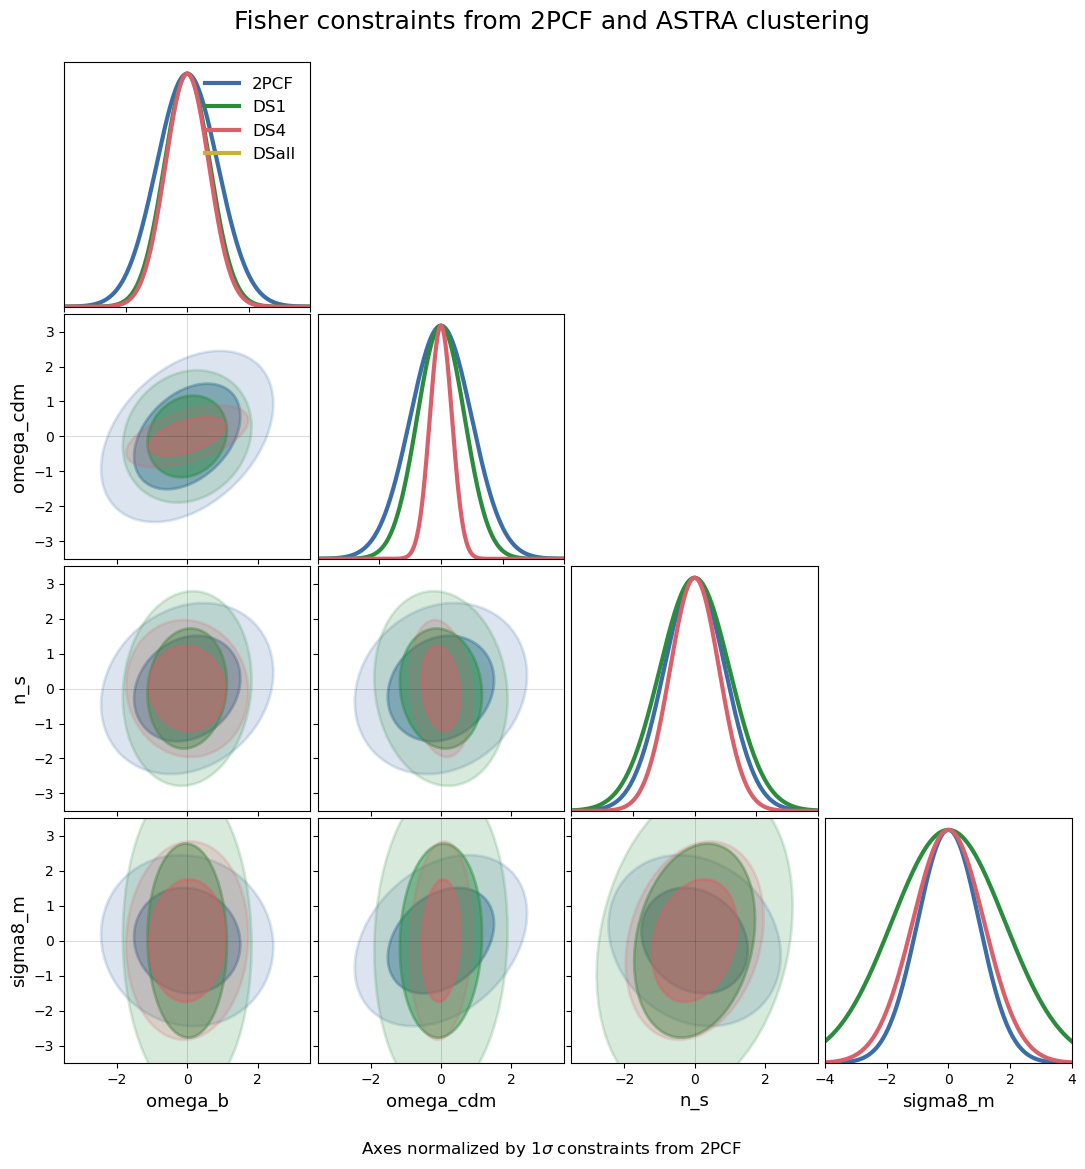

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.patches import Ellipse
from scipy.stats import chi2

# ============================================================
# LOAD DATA
# ============================================================

%cd /global/homes/h/hugon/home/acm
print('s_min=5Mpc/h')

data_cov   = np.load(
    "dataset_covariance_astra_160_1_250_200.npz",
    allow_pickle=True
)

data_deriv = np.load(
    "dataset_derivatives_astra_64_1_250_200.npz",
    allow_pickle=True
)

COSMOLOGY_FILE = "/global/homes/h/hugon/home/acm/nb/cosmologies.csv"

cosmo_df = pd.read_csv(COSMOLOGY_FILE)
cosmo_df.columns = cosmo_df.columns.str.strip()

cosmo_df["cosmo_id"] = (
    cosmo_df["root"]
    .str.extract(r"cosm(\d+)")
    .astype(int)
)

cosmo_df = cosmo_df.set_index("cosmo_id")

# ============================================================
# PARAMETERS
# ============================================================

FID_COSMO = 0

params = [
    "omega_b",
    "omega_cdm",
    "n_s",
    "sigma8_m"
]

pairs = {
    "omega_b":   (100, 101),
    "omega_cdm": (102, 103),
    "n_s":       (104, 105),
    "sigma8_m":  (112, 113),
}

colors = {
    "2PCF":  "#3b6ea8",
    "DS1":   "#2b8c3e",
    "DS4":   "#d95f6a",
    "DSall": "#c9b037",
}

# ============================================================
# GROUPS
# ============================================================

def group_by_cosmo(data):

    grouped = {}

    for i, cid in enumerate(data["cosmo_id"]):
        grouped.setdefault(int(cid), []).append(i)

    return grouped

group_cov   = group_by_cosmo(data_cov)
group_deriv = group_by_cosmo(data_deriv)

idx_fid = group_cov[FID_COSMO]

print("fiducial mocks =", len(idx_fid))

# ============================================================
# HELPERS
# ============================================================

def stack(arr):

    return np.vstack([
        np.asarray(x, dtype=float)
        for x in arr
    ])

# ============================================================
# VECTOR STRUCTURE
# ============================================================

# each block:
# 25 monopole + 25 quadrupole = 50

idx_cross_q1 = np.r_[0:50]
idx_cross_q2 = np.r_[50:100]
idx_cross_q3 = np.r_[100:150]
idx_cross_q4 = np.r_[150:200]

idx_auto_q1  = np.r_[200:250]
idx_auto_q2  = np.r_[250:300]
idx_auto_q3  = np.r_[300:350]
idx_auto_q4  = np.r_[350:400]

# ============================================================
# CONFIGS
# ============================================================

idx_ds1 = np.r_[
    idx_cross_q1,
    idx_auto_q1
]

idx_ds4 = np.r_[
    idx_cross_q4,
    idx_auto_q4
]

idx_dsall = np.r_[0:400]

idx_pcf = np.r_[0:50]

# ============================================================
# BUILD FISHER
# ============================================================

def build_fisher_from_data(
    cov_vectors,
    deriv_vectors,
    indices
):
    
    # ========================================================
    # COVARIANCE
    # ========================================================

    X = np.vstack([
        np.asarray(v, dtype=float)[indices]
        for v in cov_vectors
    ])

    cov = np.cov(X, rowvar=False)

    print("Cov rank =", np.linalg.matrix_rank(cov))
    print("Cov shape =", cov.shape)
    eig_cov = np.linalg.eigvalsh(cov)

    print("Cov eig min =", eig_cov.min())
    print("Cov eig max =", eig_cov.max())


    nmock = len(X)
    ndata = cov.shape[0]

    hartlap = (nmock - ndata - 2) / (nmock - 1)

    print()
    print("nmock =", nmock)
    print("ndata =", ndata)
    print("Hartlap =", hartlap)

    cov += 1e-8 * np.eye(ndata)

    Cinv = hartlap * np.linalg.inv(cov)

    # ========================================================
    # DERIVATIVES
    # ========================================================

    derivs = {}

    for pname, (cp, cm) in pairs.items():

        Xp = np.vstack([
            np.asarray(v, dtype=float)[indices]
            for v in deriv_vectors[group_deriv[cp]]
        ]).mean(axis=0)

        Xm = np.vstack([
            np.asarray(v, dtype=float)[indices]
            for v in deriv_vectors[group_deriv[cm]]
        ]).mean(axis=0)

        delta = (
            cosmo_df.loc[cp, pname]
            - cosmo_df.loc[cm, pname]
        )

        derivs[pname] = (Xp - Xm) / delta

    # ========================================================
    # FISHER MATRIX
    # ========================================================

    plist = list(derivs.keys())

    F = np.zeros((len(plist), len(plist)))

    for i, pi in enumerate(plist):

        di = derivs[pi]

        for j, pj in enumerate(plist):

            dj = derivs[pj]

            F[i,j] = di @ Cinv @ dj

    return F

# ============================================================
# BUILD MATRICES
# ============================================================

print("\n===== 2PCF =====")

F_pcf = build_fisher_from_data(
    data_cov["pcf"][idx_fid],
    data_deriv["pcf"],
    idx_pcf
)

print("\n===== DS1 =====")

F_ds1 = build_fisher_from_data(
    data_cov["ds_z"][idx_fid],
    data_deriv["ds_z"],
    idx_ds1
)

print("\n===== DS4 =====")

F_ds4 = build_fisher_from_data(
    data_cov["ds_z"][idx_fid],
    data_deriv["ds_z"],
    idx_ds4
)

print("\n===== DS ALL =====")

F_dsall = build_fisher_from_data(
    data_cov["ds_z"][idx_fid],
    data_deriv["ds_z"],
    idx_dsall
)

# ============================================================
# PARAMETER COVARIANCES
# ============================================================

covs = {
    "2PCF":  np.linalg.inv(F_pcf),
    "DS1":   np.linalg.inv(F_ds1),
    "DS4":   np.linalg.inv(F_ds4),
    "DSall": np.linalg.inv(F_dsall),
}

# ============================================================
# ELLIPSE DRAWING
# ============================================================

def draw_ellipse(ax, cov, color, alpha1=0.45, alpha2=0.18):

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]

    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(
        np.arctan2(*vecs[:,0][::-1])
    )

    # 68% and 95%
    scales = [
        np.sqrt(chi2.ppf(0.95, 2)),
        np.sqrt(chi2.ppf(0.68, 2)),
    ]

    alphas = [alpha2, alpha1]

    for scale, alpha in zip(scales, alphas):

        width  = 2 * scale * np.sqrt(vals[0])
        height = 2 * scale * np.sqrt(vals[1])

        ell = Ellipse(
            xy=(0,0),
            width=width,
            height=height,
            angle=theta,
            facecolor=color,
            edgecolor=color,
            lw=2,
            alpha=alpha
        )

        ax.add_patch(ell)

# ============================================================
# NORMALIZATION
# ============================================================

sigmas_ref = np.sqrt(
    np.diag(covs["2PCF"])
)

# ============================================================
# PLOT
# ============================================================

npar = len(params)

fig, axes = plt.subplots(
    npar,
    npar,
    figsize=(13,13)
)

plt.subplots_adjust(
    wspace=0.03,
    hspace=0.03
)

for i in range(npar):

    for j in range(npar):

        ax = axes[i,j]

        # ====================================================
        # UPPER TRIANGLE
        # ====================================================

        if j > i:
            ax.axis("off")
            continue

        # ====================================================
        # DIAGONAL
        # ====================================================

        if i == j:

            for name, cov in covs.items():

                sigma = np.sqrt(cov[i,i])

                sigma /= sigmas_ref[i]

                x = np.linspace(-4, 4, 500)

                y = np.exp(
                    -x**2 / (2*sigma**2)
                )

                y /= y.max()

                ax.plot(
                    x,
                    y,
                    color=colors[name],
                    lw=3,
                    label=name if i == 0 else None
                )

            ax.set_xlim(-4, 4)
            ax.set_ylim(0, 1.05)

            ax.set_yticks([])

        # ====================================================
        # LOWER TRIANGLE
        # ====================================================

        else:

            for name, cov in covs.items():

                sub = cov[
                    np.ix_([j,i],[j,i])
                ].copy()

                # normalize by 2PCF sigmas
                sub[0,0] /= sigmas_ref[j]**2
                sub[1,1] /= sigmas_ref[i]**2
                sub[0,1] /= sigmas_ref[j]*sigmas_ref[i]
                sub[1,0] /= sigmas_ref[j]*sigmas_ref[i]

                draw_ellipse(
                    ax,
                    sub,
                    colors[name]
                )

            ax.set_xlim(-3.5, 3.5)
            ax.set_ylim(-3.5, 3.5)

            ax.axhline(0, color="k", lw=0.5, alpha=0.2)
            ax.axvline(0, color="k", lw=0.5, alpha=0.2)

        # ====================================================
        # STYLE
        # ====================================================

        if i != npar - 1:
            ax.set_xticklabels([])

        if j != 0:
            ax.set_yticklabels([])

        if i == npar - 1:
            ax.set_xlabel(
                params[j],
                fontsize=13
            )

        if j == 0 and i > 0:
            ax.set_ylabel(
                params[i],
                fontsize=13
            )

# ============================================================
# LEGEND
# ============================================================

axes[0,0].legend(
    loc="upper right",
    fontsize=12,
    frameon=False
)

plt.suptitle(
    "Fisher constraints from 2PCF and ASTRA clustering",
    fontsize=18,
    y=0.92
)
fig.text(
    0.5,
    0.04,
    r"Axes normalized by $1\sigma$ constraints from 2PCF",
    ha="center",
    fontsize=12
)
print("\n==============================")
print("FISHER DIAGNOSTICS")
print("==============================")

for name, F in zip(
    ["2PCF", "DS1", "DS4", "DSall"],
    [F_pcf, F_ds1, F_ds4, F_dsall]
):

    eig = np.linalg.eigvalsh(F)

    print(f"\n{name}")
    print("Condition number :", np.linalg.cond(F))
    print("Min eigenvalue   :", eig.min())
    print("Max eigenvalue   :", eig.max())
    print("Positive definite:", np.all(eig > 0))

plt.show()

DS UNIQUEMENT :

- les cross-correlations
- ET seulement les monopoles (pas quadru, peu informatifs et augmentent le bruit S/N, plus stable, 400--> 100 dimensions)

2PCF :
- monopole
- quadrupole



/global/u1/h/hugon/home/acm

ndata = 50
nmock = 160
hartlap = 0.6792452830188679

ndata = 25
nmock = 160
hartlap = 0.8364779874213837

ndata = 25
nmock = 160
hartlap = 0.8364779874213837

ndata = 100
nmock = 160
hartlap = 0.36477987421383645

ndata = 150
nmock = 160
hartlap = 0.050314465408805034


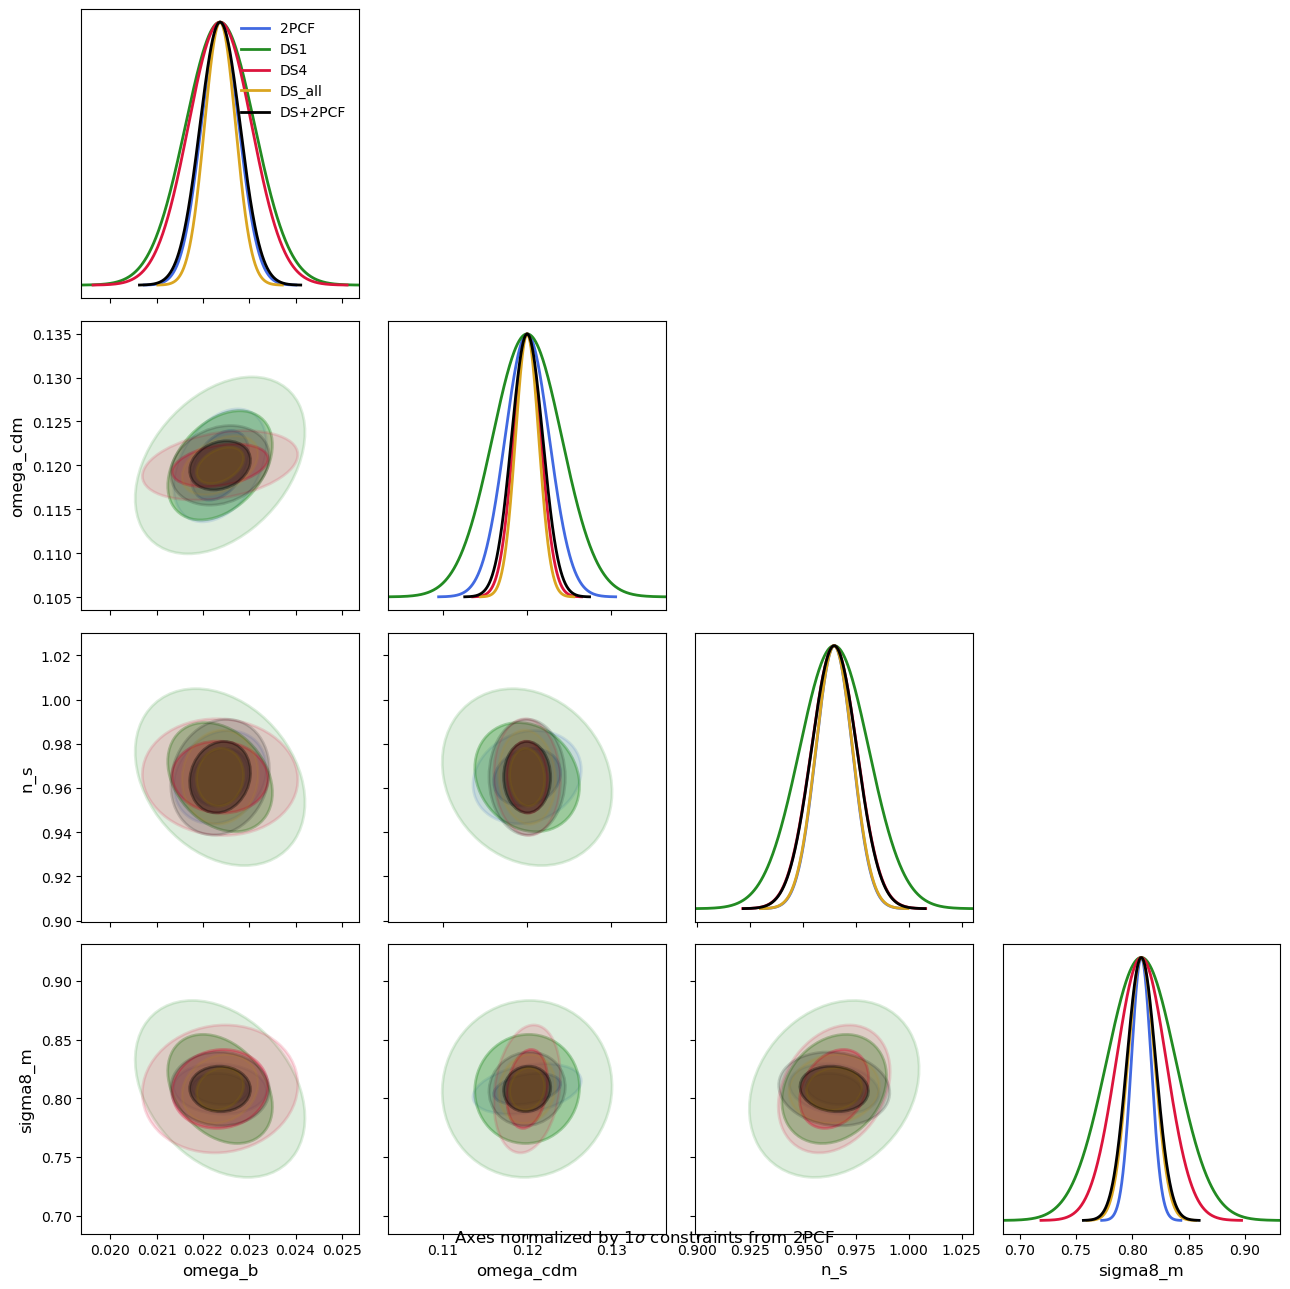

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.patches import Ellipse
from scipy.stats import chi2

# ============================================================
# LOAD
# ============================================================

%cd /global/homes/h/hugon/home/acm

data_cov   = np.load(
    "dataset_covariance_astra_160_1_250_200.npz",
    allow_pickle=True
)

data_deriv = np.load(
    "dataset_derivatives_astra_64_1_250_200.npz",
    allow_pickle=True
)

COSMOLOGY_FILE = "/global/homes/h/hugon/home/acm/nb/cosmologies.csv"

cosmo_df = pd.read_csv(COSMOLOGY_FILE)
cosmo_df.columns = cosmo_df.columns.str.strip()

cosmo_df["cosmo_id"] = (
    cosmo_df["root"]
    .str.extract(r"cosm(\d+)")
    .astype(int)
)

cosmo_df = cosmo_df.set_index("cosmo_id")

# ============================================================
# SETTINGS
# ============================================================

FID_COSMO = 0

params = [
    "omega_b",
    "omega_cdm",
    "n_s",
    "sigma8_m"
]

pairs = {
    "omega_b":   (100, 101),
    "omega_cdm": (102, 103),
    "n_s":       (104, 105),
    "sigma8_m":  (112, 113),
}

colors = {
    "2PCF": "royalblue",
    "DS1": "forestgreen",
    "DS4": "crimson",
    "DS_all": "goldenrod",
    "DS+2PCF": "black",
}

# ============================================================
# GROUPS
# ============================================================

group_cov = {}

for i, cid in enumerate(data_cov["cosmo_id"]):
    group_cov.setdefault(int(cid), []).append(i)

group_deriv = {}

for i, cid in enumerate(data_deriv["cosmo_id"]):
    group_deriv.setdefault(int(cid), []).append(i)

idx_fid = group_cov[FID_COSMO]

# ============================================================
# HELPERS
# ============================================================

def stack(arr):
    return np.vstack([
        np.asarray(x, dtype=float)
        for x in arr
    ])

# ============================================================
# VECTOR STRUCTURE
# ============================================================

# ONLY MONOPOLES
# each block = 25 bins

idx_cross_q1 = np.r_[0:25]
idx_cross_q2 = np.r_[50:75]
idx_cross_q3 = np.r_[100:125]
idx_cross_q4 = np.r_[150:175]

idx_auto_q1  = np.r_[200:225]
idx_auto_q2  = np.r_[250:275]
idx_auto_q3  = np.r_[300:325]
idx_auto_q4  = np.r_[350:375]

# ============================================================
# CONFIGS
# ============================================================

idx_ds1 = np.r_[
    idx_cross_q1,
]

idx_ds4 = np.r_[
    idx_cross_q4,
]

idx_dsall = np.r_[
    idx_cross_q1,
    idx_cross_q2,
    idx_cross_q3,
    idx_cross_q4,
]

idx_pcf = np.r_[0:50]

# ============================================================
# FISHER BUILDER
# ============================================================

def build_fisher(
    cov_vectors,
    deriv_vectors,
    indices
):

    X = np.vstack([
        np.asarray(x, dtype=float)[indices]
        for x in cov_vectors
    ])

    cov = np.cov(X, rowvar=False)

    nmock = len(X)
    p = cov.shape[0]

    hartlap = (nmock - p - 2) / (nmock - 1)

    print()
    print("ndata =", p)
    print("nmock =", nmock)
    print("hartlap =", hartlap)

    Cinv = hartlap * np.linalg.inv(
        cov + 1e-8 * np.eye(p)
    )

    derivs = {}

    for pname, (cp, cm) in pairs.items():

        Xp = np.vstack([
            np.asarray(x, dtype=float)[indices]
            for x in deriv_vectors[group_deriv[cp]]
        ]).mean(axis=0)

        Xm = np.vstack([
            np.asarray(x, dtype=float)[indices]
            for x in deriv_vectors[group_deriv[cm]]
        ]).mean(axis=0)

        delta = (
            cosmo_df.loc[cp, pname]
            - cosmo_df.loc[cm, pname]
        )

        derivs[pname] = (Xp - Xm) / delta

    plist = list(derivs.keys())

    F = np.zeros((len(plist), len(plist)))

    for i, pi in enumerate(plist):

        di = derivs[pi]

        for j, pj in enumerate(plist):

            dj = derivs[pj]

            F[i,j] = di @ Cinv @ dj

    return F

# ============================================================
# BUILD FISHERS
# ============================================================

F_pcf = build_fisher(
    data_cov["pcf"][idx_fid],
    data_deriv["pcf"],
    idx_pcf
)

F_ds1 = build_fisher(
    data_cov["ds_z"][idx_fid],
    data_deriv["ds_z"],
    idx_ds1
)

F_ds4 = build_fisher(
    data_cov["ds_z"][idx_fid],
    data_deriv["ds_z"],
    idx_ds4
)

F_dsall = build_fisher(
    data_cov["ds_z"][idx_fid],
    data_deriv["ds_z"],
    idx_dsall
)

# ============================================================
# DS + 2PCF
# ============================================================

X_combo_cov = [
    np.concatenate([
        np.asarray(ds)[idx_dsall],
        np.asarray(pcf)[idx_pcf]
    ])
    for ds, pcf in zip(
        data_cov["ds_z"][idx_fid],
        data_cov["pcf"][idx_fid]
    )
]

X_combo_deriv = []

for ds, pcf in zip(
    data_deriv["ds_z"],
    data_deriv["pcf"]
):

    X_combo_deriv.append(
        np.concatenate([
            np.asarray(ds)[idx_dsall],
            np.asarray(pcf)[idx_pcf]
        ])
    )

X_combo_deriv = np.array(X_combo_deriv, dtype=object)

F_combo = build_fisher(
    X_combo_cov,
    X_combo_deriv,
    np.r_[0:150]
)

# ============================================================
# PARAM COV
# ============================================================

covs = {
    "2PCF": np.linalg.inv(F_pcf),
    "DS1": np.linalg.inv(F_ds1),
    "DS4": np.linalg.inv(F_ds4),
    "DS_all": np.linalg.inv(F_dsall),
    "DS+2PCF": np.linalg.inv(F_combo),
}

# ============================================================
# FIDUCIAL VALUES
# ============================================================

fid = cosmo_df.loc[FID_COSMO]

fidvals = np.array([
    fid[p]
    for p in params
])

# ============================================================
# ELLIPSES
# ============================================================

def draw_ellipse(ax, cov, center, color, nsigma=1, alpha=0.3):

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]

    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(
        np.arctan2(*vecs[:,0][::-1])
    )

    scale = np.sqrt(
        chi2.ppf(
            0.68 if nsigma == 1 else 0.95,
            2
        )
    )

    width  = 2 * scale * np.sqrt(vals[0])
    height = 2 * scale * np.sqrt(vals[1])

    ell = Ellipse(
        xy=center,
        width=width,
        height=height,
        angle=theta,
        facecolor=color,
        edgecolor=color,
        lw=2,
        alpha=alpha
    )

    ax.add_patch(ell)

# ============================================================
# PLOT
# ============================================================

npar = len(params)

fig, axes = plt.subplots(
    npar,
    npar,
    figsize=(13,13)
)

nsig_plot = 4

for i in range(npar):

    for j in range(npar):

        ax = axes[i,j]

        if j > i:
            ax.axis("off")
            continue

        # ====================================================
        # AUTO AXIS LIMITS
        # ====================================================

        sig_i = max([
            np.sqrt(cov[i,i])
            for cov in covs.values()
        ])

        sig_j = max([
            np.sqrt(cov[j,j])
            for cov in covs.values()
        ])

        x0 = fidvals[j]
        y0 = fidvals[i]

        ax.set_xlim(
            x0 - nsig_plot*sig_j,
            x0 + nsig_plot*sig_j
        )

        if i != j:
            ax.set_ylim(
                y0 - nsig_plot*sig_i,
                y0 + nsig_plot*sig_i
            )

        # ====================================================
        # DIAGONAL
        # ====================================================

        if i == j:

            for name, cov in covs.items():

                sigma = np.sqrt(cov[i,i])

                x = np.linspace(
                    x0 - nsig_plot*sigma,
                    x0 + nsig_plot*sigma,
                    500
                )

                y = np.exp(
                    -(x-x0)**2 / (2*sigma**2)
                )

                y /= y.max()

                ax.plot(
                    x,
                    y,
                    color=colors[name],
                    lw=2,
                    label=name if i == 0 else None
                )

            ax.set_yticks([])

        # ====================================================
        # LOWER TRIANGLE
        # ====================================================

        else:

            for name, cov in covs.items():

                subcov = cov[
                    np.ix_([j,i],[j,i])
                ]

                center = (
                    fidvals[j],
                    fidvals[i]
                )

                draw_ellipse(
                    ax,
                    subcov,
                    center,
                    colors[name],
                    nsigma=2,
                    alpha=0.15
                )

                draw_ellipse(
                    ax,
                    subcov,
                    center,
                    colors[name],
                    nsigma=1,
                    alpha=0.35
                )

        # ====================================================
        # LABELS
        # ====================================================

        if i == npar - 1:
            ax.set_xlabel(params[j], fontsize=12)
        else:
            ax.set_xticklabels([])

        if j == 0 and i > 0:
            ax.set_ylabel(params[i], fontsize=12)
        else:
            if i != j:
                ax.set_yticklabels([])

# ============================================================
# LEGEND
# ============================================================
fig.text(
    0.5,
    0.04,
    r"Axes normalized by $1\sigma$ constraints from 2PCF",
    ha="center",
    fontsize=12
)

axes[0,0].legend(
    loc="upper right",
    fontsize=10,
    frameon=False
)

plt.tight_layout()
plt.show()



Reconstructing: 2PCF


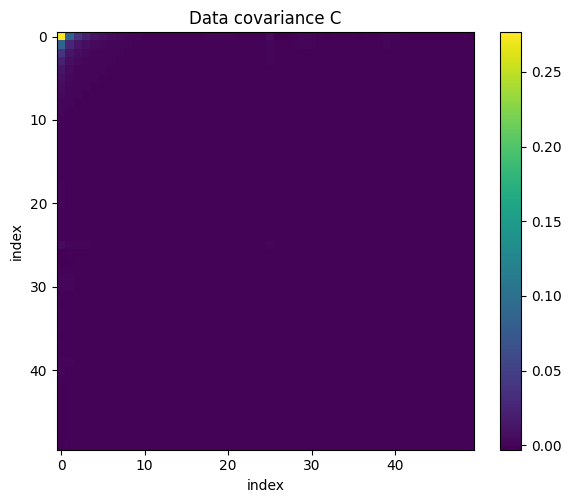

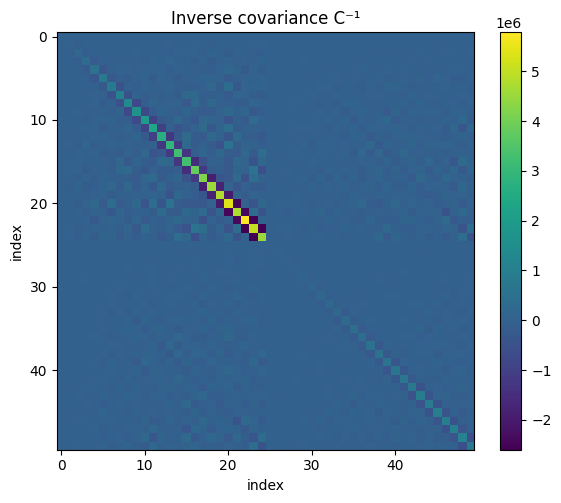

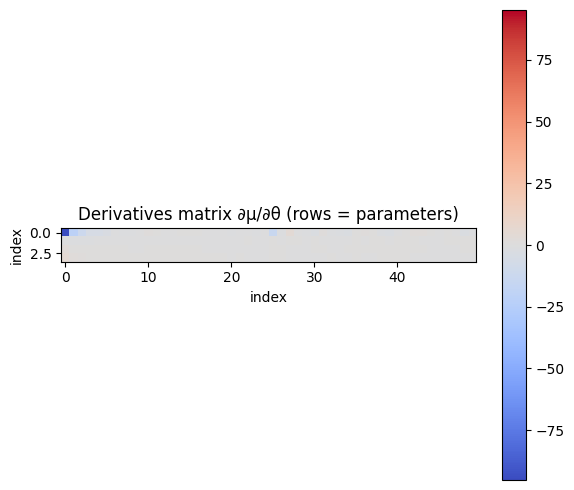

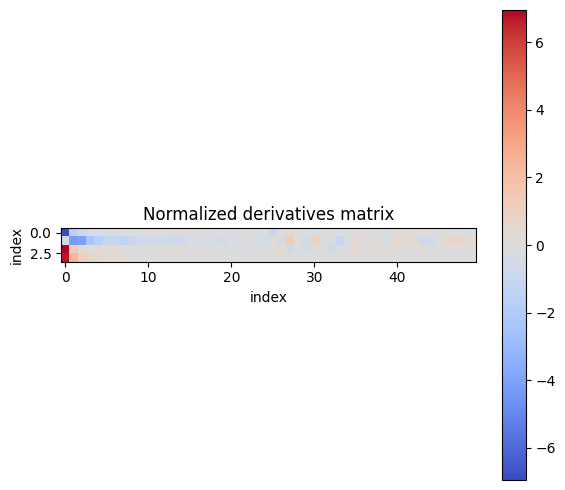

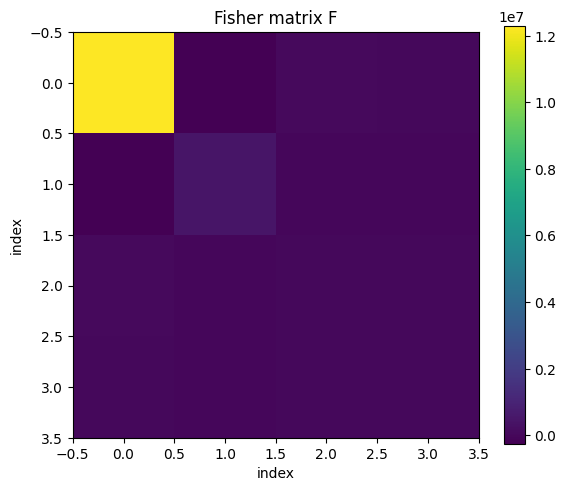

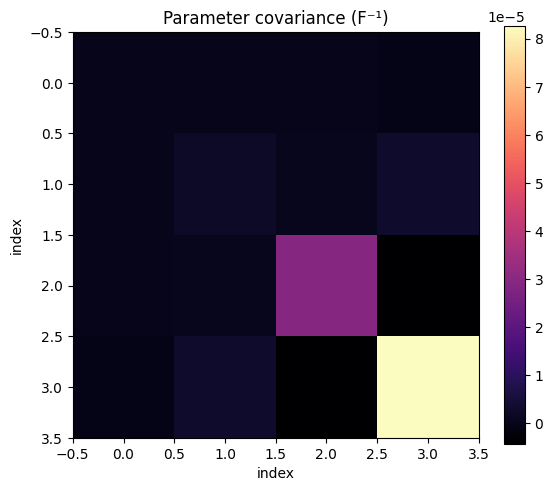

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PLOT UTILITY
# ============================================================

def plot_matrix(mat, title, cmap="viridis", symmetric=False):
    mat = np.asarray(mat)

    plt.figure(figsize=(6, 5))

    if symmetric:
        vmax = np.nanmax(np.abs(mat))
        if vmax == 0:
            vmax = 1.0
        plt.imshow(mat, cmap=cmap, vmin=-vmax, vmax=vmax)
    else:
        plt.imshow(mat, cmap=cmap)

    plt.colorbar()
    plt.title(title)
    plt.xlabel("index")
    plt.ylabel("index")
    plt.tight_layout()
    plt.show()


# ============================================================
# 1. REBUILD COV + Cinv + DERIVATIVES FROM YOUR BUILD_FISHER
# ============================================================

def reconstruct_fisher_inputs(name, cov_vectors, deriv_vectors, indices):

    print(f"\nReconstructing: {name}")

    # ----------------------------
    # DATA MATRIX
    # ----------------------------
    X = np.vstack([
        np.asarray(v, dtype=float)[indices]
        for v in cov_vectors
    ])

    cov = np.cov(X, rowvar=False)

    # ----------------------------
    # STABILIZATION
    # ----------------------------
    cov_reg = cov + 1e-8 * np.eye(cov.shape[0])

    # Hartlap
    nmock = len(X)
    ndata = cov.shape[0]
    hartlap = (nmock - ndata - 2) / (nmock - 1)

    try:
        Cinv = hartlap * np.linalg.inv(cov_reg)
    except np.linalg.LinAlgError:
        Cinv = hartlap * np.linalg.pinv(cov_reg)

    # ----------------------------
    # DERIVATIVES
    # ----------------------------
    derivs_local = {}

    for pname, (cp, cm) in pairs.items():

        Xp = np.vstack([
            np.asarray(v, dtype=float)[indices]
            for v in deriv_vectors[group_deriv[cp]]
        ]).mean(axis=0)

        Xm = np.vstack([
            np.asarray(v, dtype=float)[indices]
            for v in deriv_vectors[group_deriv[cm]]
        ]).mean(axis=0)

        delta = (
            cosmo_df.loc[cp, pname]
            - cosmo_df.loc[cm, pname]
        )

        derivs_local[pname] = (Xp - Xm) / delta

    return cov, Cinv, derivs_local


# ============================================================
# 2. PICK YOUR CONFIG (EXAMPLE: 2PCF)
# ============================================================

cov, Cinv, derivs_local = reconstruct_fisher_inputs(
    "2PCF",
    data_cov["pcf"][idx_fid],
    data_deriv["pcf"],
    idx_pcf
)


# ============================================================
# 3. PLOTS: C AND C⁻¹
# ============================================================

plot_matrix(cov, "Data covariance C")
plot_matrix(Cinv, "Inverse covariance C⁻¹")


# ============================================================
# 4. DERIVATIVES MATRIX
# ============================================================

param_list = list(params)
n_params = len(param_list)
n_bins = len(next(iter(derivs_local.values())))

D = np.zeros((n_params, n_bins))

for i, p in enumerate(param_list):
    D[i] = derivs_local[p]

plot_matrix(
    D,
    "Derivatives matrix ∂μ/∂θ (rows = parameters)",
    cmap="coolwarm",
    symmetric=True
)


# ============================================================
# 5. NORMALIZED DERIVATIVES
# ============================================================

D_norm = np.zeros_like(D)

for i in range(D.shape[0]):
    std = np.std(D[i])
    if std > 0:
        D_norm[i] = D[i] / std

plot_matrix(
    D_norm,
    "Normalized derivatives matrix",
    cmap="coolwarm",
    symmetric=True
)


# ============================================================
# 6. FISHER + COVARIANCE OF PARAMETERS
# ============================================================

F = np.zeros((n_params, n_params))

for i, pi in enumerate(param_list):
    for j, pj in enumerate(param_list):
        F[i, j] = D[i] @ Cinv @ D[j]

Cov_theta = np.linalg.pinv(F)

plot_matrix(F, "Fisher matrix F", cmap="viridis")
plot_matrix(Cov_theta, "Parameter covariance (F⁻¹)", cmap="magma")

<class 'numpy.ndarray'>
(500, 850)
float64
NaNs: 0
Infs: 0
Data vector shape: (500, 850)
Cov shape: (850, 850)


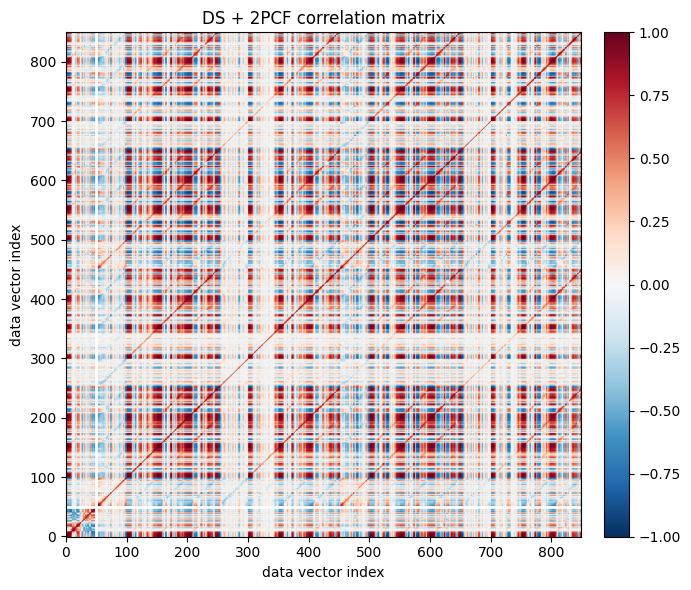

In [17]:
import numpy as np
import matplotlib.pyplot as plt



# ============================================================
# 1. LOAD DATA
# ============================================================

data_cov = np.load(
    "dataset_covariance_astra_1500_1_250_200.npz",
    allow_pickle=True
)

# ============================================================
# 2. EXTRACT OBSERVABLES
# ============================================================

pcf = data_cov["pcf"]  # (n_cosmo, 50)

# Density-split (on combine r + z)
ds_r = data_cov["ds_r"]   # (n_cosmo, 400)
ds_z = data_cov["ds_z"]   # (n_cosmo, 400)

ds = np.concatenate([ds_r, ds_z], axis=1)  # (n_cosmo, 800)

# ============================================================
# 3. BUILD DATA VECTOR
# ============================================================


# shape = (n_cosmo, 50 + 800)
data_vector = np.concatenate([pcf, ds], axis=1)

data_vector = np.asarray(data_vector)

data_vector = data_vector.astype(np.float64)


print(type(data_vector))
print(data_vector.shape)
print(data_vector.dtype)

print("NaNs:", np.isnan(data_vector).sum())
print("Infs:", np.isinf(data_vector).sum())

print("Data vector shape:", data_vector.shape)

# ============================================================
# 4. COVARIANCE MATRIX
# ============================================================

# IMPORTANT: covariance over cosmologies
cov = np.cov(data_vector, rowvar=False)

print("Cov shape:", cov.shape)

# ============================================================
# 5. CORRELATION MATRIX
# ============================================================

def correlation_matrix(C):
    std = np.sqrt(np.diag(C))
    return C / np.outer(std, std)

R = correlation_matrix(cov)

# ============================================================
# 6. PLOT FUNCTION
# ============================================================

def plot_corr_matrix_block(R, split_index, title=""):
    plt.figure(figsize=(7, 6))

    im = plt.imshow(
        R,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        origin="lower",
        aspect="auto"
    )

    # séparation 2PCF / DS
    plt.axhline(split_index - 0.5, color="white", lw=2)
    plt.axvline(split_index - 0.5, color="white", lw=2)

    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.title(title)
    plt.xlabel("data vector index")
    plt.ylabel("data vector index")

    plt.tight_layout()
    plt.show()

# ============================================================
# 7. DEFINE BLOCK SPLIT
# ============================================================

n_pcf = pcf.shape[1]   # = 50
split_index = n_pcf

# ============================================================
# 8. PLOT FINAL FIGURE
# ============================================================

plot_corr_matrix_block(
    R,
    split_index=split_index,
    title="DS + 2PCF correlation matrix"
)

2PCF shape: (50, 50)
DS shape: (800, 800)


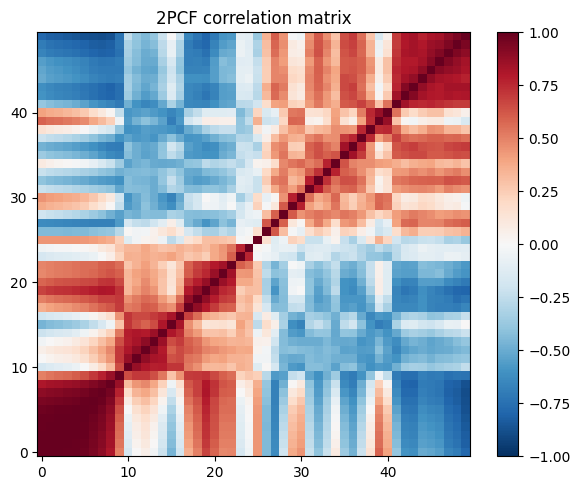

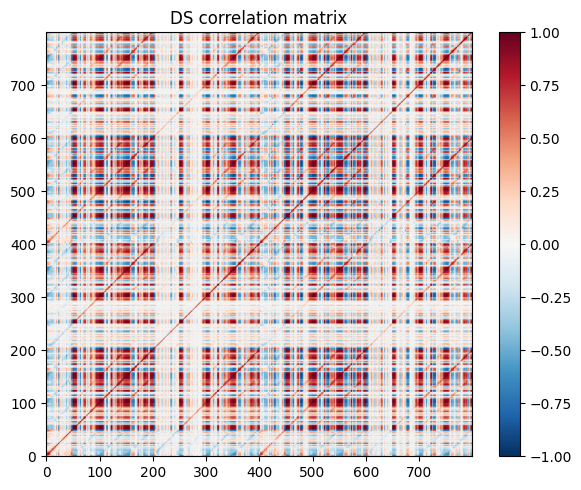

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD DATA
# ============================================================

data = np.load(
    "dataset_covariance_astra_1500_1_250_200.npz",
    allow_pickle=True
)

# ============================================================
# 2. EXTRACT OBSERVABLES
# ============================================================

pcf = np.asarray(data["pcf"], dtype=np.float64)      # (500, 50)

ds_r = np.asarray(data["ds_r"], dtype=np.float64)    # (500, 400)
ds_z = np.asarray(data["ds_z"], dtype=np.float64)    # (500, 400)

ds = np.concatenate([ds_r, ds_z], axis=1)            # (500, 800)

# ============================================================
# 3. UTILITY: COVARIANCE + CORRELATION
# ============================================================

def covariance(X):
    X = X - X.mean(axis=0)
    return (X.T @ X) / (X.shape[0] - 1)

def correlation_matrix(C):
    std = np.sqrt(np.diag(C))
    return C / np.outer(std, std)

def plot_matrix(R, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1, origin="lower", aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ============================================================
# 4. 2PCF MATRIX
# ============================================================

cov_pcf = covariance(pcf)
R_pcf = correlation_matrix(cov_pcf)

print("2PCF shape:", R_pcf.shape)

# ============================================================
# 5. DS MATRIX
# ============================================================

cov_ds = covariance(ds)
R_ds = correlation_matrix(cov_ds)

print("DS shape:", R_ds.shape)

# ============================================================
# 6. PLOTS
# ============================================================

plot_matrix(R_pcf, "2PCF correlation matrix")
plot_matrix(R_ds, "DS correlation matrix")

# V4

/global/u1/h/hugon/home/acm
s_min = 5 Mpc/h

FIDUCIAL MOCKS
N mocks = 500

DATA VECTOR CONFIGURATIONS
2PCF bins  : 50
DS1 bins   : 100
DS4 bins   : 100
DSall bins : 400

2PCF
Data matrix shape : (500, 50)

COVARIANCE
---------------------------
Shape          : (50, 50)
Rank           : 50
Min eigenvalue : 7.54809140075704e-08
Max eigenvalue : 0.31203970960375116

HARTLAP
---------------------------
Nmock   : 500
Ndata   : 50
Hartlap : 0.8977955911823647

INVERSION
---------------------------
Inverse successful : True

PARAMETER STEPS
---------------------------
omega_b      delta = 8.900000e-04
omega_cdm    delta = 7.900000e-03
n_s          delta = 2.000000e-02
sigma8_m     delta = 3.201300e-02

FISHER DIAGNOSTICS
---------------------------
Condition number : 1020.8148150912582
Min eigenvalue   : 12042.504329249923
Max eigenvalue   : 12293166.830098934
Positive definite: True

DS1
Data matrix shape : (500, 100)

COVARIANCE
---------------------------
Shape          : (100, 100)
Rank 


COVARIANCE
---------------------------
Shape          : (450, 450)
Rank           : 450
Min eigenvalue : 8.306549133422845e-10
Max eigenvalue : 7.945795811776909

HARTLAP
---------------------------
Nmock   : 500
Ndata   : 450
Hartlap : 0.09619238476953908

WARNING
---------------------------
Hartlap very small
Covariance likely noisy

INVERSION
---------------------------
Inverse successful : True

PARAMETER STEPS
---------------------------
omega_b      delta = 8.900000e-04
omega_cdm    delta = 7.900000e-03
n_s          delta = 2.000000e-02
sigma8_m     delta = 3.201300e-02

FISHER DIAGNOSTICS
---------------------------
Condition number : 1880.2231988784606
Min eigenvalue   : 16379.515403524507
Max eigenvalue   : 30797144.848112315
Positive definite: True

PARAMETER CONSTRAINTS

2PCF
---------------------------
omega_b      2.886858e-04
omega_cdm    1.549444e-03
n_s          5.415325e-03
sigma8_m     9.087657e-03

DS1
---------------------------
omega_b      3.344837e-04
omega_cdm 

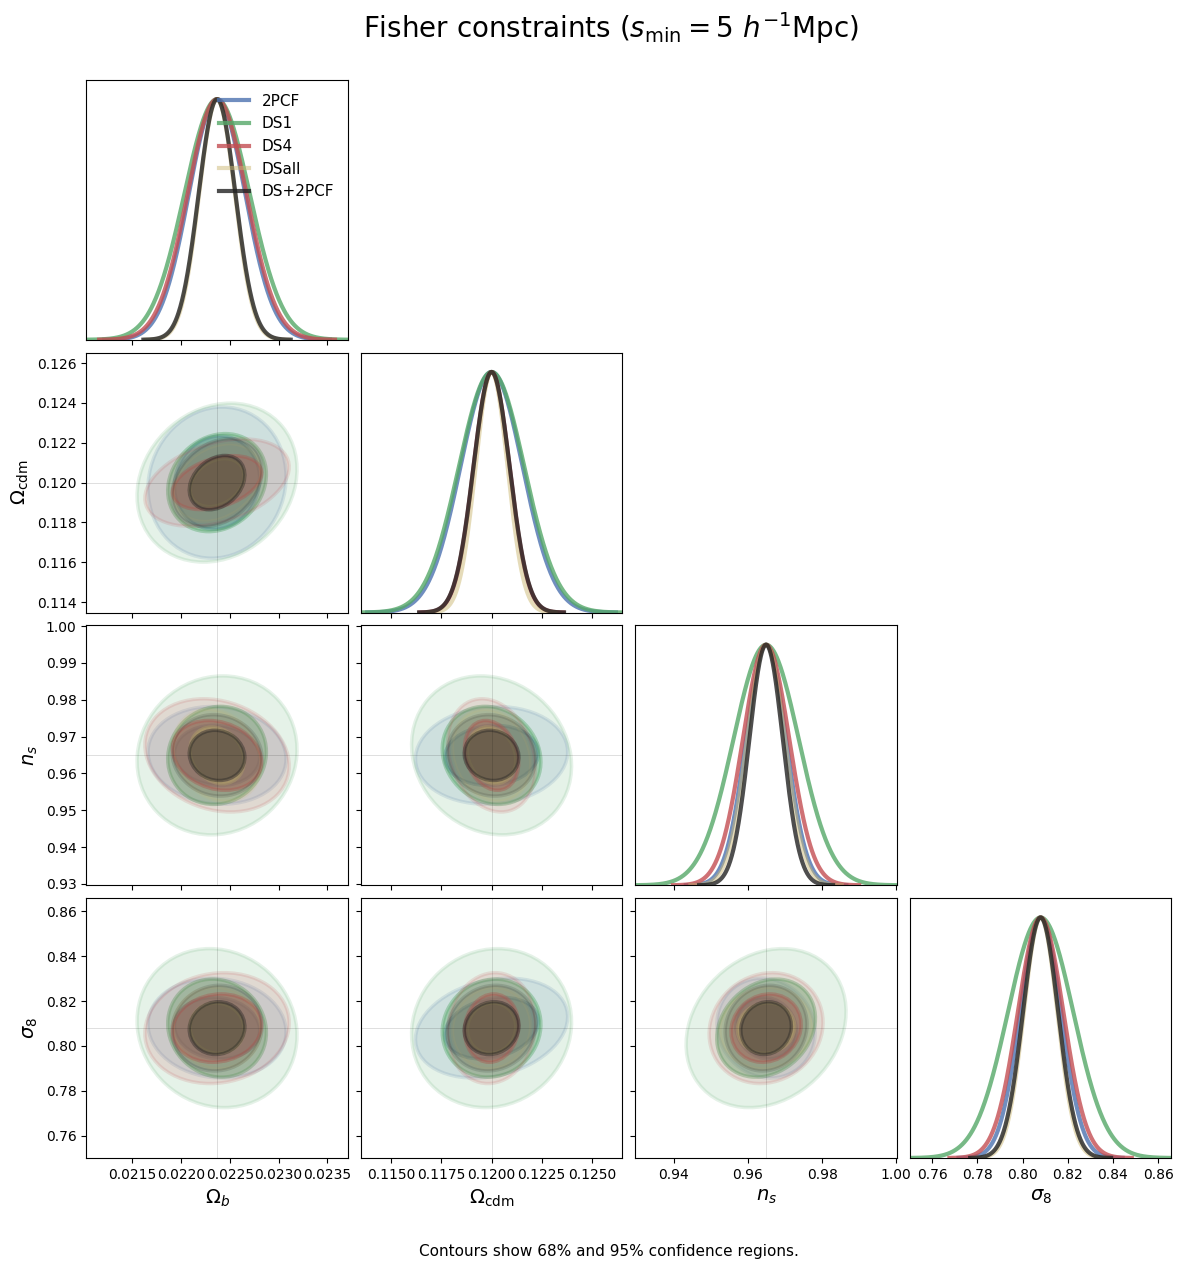

In [5]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.patches import Ellipse
from scipy.stats import chi2

# ============================================================
# LOAD
# ============================================================

%cd /global/homes/h/hugon/home/acm

S_MIN = 5

print(f"s_min = {S_MIN} Mpc/h")

data_cov = np.load(
    # "dataset_covariance_astra_160_1_250_200.npz",
    "dataset_covariance_astra_1500_1_250_200.npz",
    allow_pickle=True
)

data_deriv = np.load(
    "dataset_derivatives_astra_64_1_250_200.npz",
    allow_pickle=True
)

COSMOLOGY_FILE = (
    "/global/homes/h/hugon/home/acm/nb/cosmologies.csv"
)

cosmo_df = pd.read_csv(COSMOLOGY_FILE)

cosmo_df.columns = (
    cosmo_df.columns.str.strip()
)

cosmo_df["cosmo_id"] = (
    cosmo_df["root"]
    .str.extract(r"cosm(\d+)")
    .astype(int)
)

cosmo_df = cosmo_df.set_index("cosmo_id")

# ============================================================
# SETTINGS
# ============================================================

FID_COSMO = 0

params = [
    "omega_b",
    "omega_cdm",
    "n_s",
    "sigma8_m"
]

param_labels = {
    "omega_b": r"$\Omega_b$",
    "omega_cdm": r"$\Omega_{\rm cdm}$",
    "n_s": r"$n_s$",
    "sigma8_m": r"$\sigma_8$",
}

pairs = {
    "omega_b":   (100, 101),
    "omega_cdm": (102, 103),
    "n_s":       (104, 105),
    "sigma8_m":  (112, 113),
}

# ============================================================
# COLORS
# ============================================================

colors = {
    "2PCF":    "#4C72B0",
    "DS1":     "#55A868",
    "DS4":     "#C44E52",
    "DSall":   "#CCB974",
    "DS+2PCF": "#222222",
}

# ============================================================
# GROUPS
# ============================================================

def group_by_cosmo(data):

    grouped = {}

    for i, cid in enumerate(data["cosmo_id"]):

        grouped.setdefault(
            int(cid),
            []
        ).append(i)

    return grouped

group_cov = group_by_cosmo(data_cov)
group_deriv = group_by_cosmo(data_deriv)

idx_fid = group_cov[FID_COSMO]

print()
print("================================================")
print("FIDUCIAL MOCKS")
print("================================================")
print("N mocks =", len(idx_fid))

# ============================================================
# VECTOR STRUCTURE
# ============================================================

# 25 monopole + 25 quadrupole

idx_cross_q1 = np.r_[0:50]
idx_cross_q2 = np.r_[50:100]
idx_cross_q3 = np.r_[100:150]
idx_cross_q4 = np.r_[150:200]

idx_auto_q1  = np.r_[200:250]
idx_auto_q2  = np.r_[250:300]
idx_auto_q3  = np.r_[300:350]
idx_auto_q4  = np.r_[350:400]

# ============================================================
# CONFIGS
# ============================================================

idx_ds1 = np.r_[
    idx_cross_q1,
    idx_auto_q1
]

idx_ds4 = np.r_[
    idx_cross_q4,
    idx_auto_q4
]

idx_dsall = np.r_[0:400]

idx_pcf = np.r_[0:50]

# ============================================================
# CONFIG SUMMARY
# ============================================================

print()
print("================================================")
print("DATA VECTOR CONFIGURATIONS")
print("================================================")

print("2PCF bins  :", len(idx_pcf))
print("DS1 bins   :", len(idx_ds1))
print("DS4 bins   :", len(idx_ds4))
print("DSall bins :", len(idx_dsall))

# ============================================================
# BUILD FISHER
# ============================================================

def build_fisher(
    name,
    cov_vectors,
    deriv_vectors,
    indices
):

    print()
    print("================================================")
    print(name)
    print("================================================")

    # ========================================================
    # BUILD DATA MATRIX
    # ========================================================

    X = np.vstack([
        np.asarray(v, dtype=float)[indices]
        for v in cov_vectors
    ])

    print("Data matrix shape :", X.shape)

    # ========================================================
    # COVARIANCE
    # ========================================================

    cov = np.cov(X, rowvar=False)

    rank = np.linalg.matrix_rank(cov)

    eig_cov = np.linalg.eigvalsh(cov)

    print()
    print("COVARIANCE")
    print("---------------------------")
    print("Shape          :", cov.shape)
    print("Rank           :", rank)
    print("Min eigenvalue :", eig_cov.min())
    print("Max eigenvalue :", eig_cov.max())

    # ========================================================
    # HARTLAP
    # ========================================================

    nmock = len(X)
    ndata = cov.shape[0]

    hartlap = (
        (nmock - ndata - 2)
        / (nmock - 1)
    )

    print()
    print("HARTLAP")
    print("---------------------------")
    print("Nmock   :", nmock)
    print("Ndata   :", ndata)
    print("Hartlap :", hartlap)

    if hartlap <= 0:

        print()
        print("WARNING")
        print("---------------------------")
        print("Hartlap correction is NEGATIVE")
        print("Covariance inversion is NOT reliable")
        print("Need more mocks or compression")

    elif hartlap < 0.2:

        print()
        print("WARNING")
        print("---------------------------")
        print("Hartlap very small")
        print("Covariance likely noisy")

    # ========================================================
    # REGULARIZATION
    # ========================================================

    cov_reg = cov + 1e-8 * np.eye(ndata)

    # ========================================================
    # INVERSE
    # ========================================================

    try:

        Cinv = hartlap * np.linalg.inv(cov_reg)

        inversion_ok = True

    except np.linalg.LinAlgError:

        print("Matrix inversion FAILED")

        Cinv = hartlap * np.linalg.pinv(cov_reg)

        inversion_ok = False

    print()
    print("INVERSION")
    print("---------------------------")
    print("Inverse successful :", inversion_ok)

    # ========================================================
    # DERIVATIVES
    # ========================================================

    derivs = {}

    print()
    print("PARAMETER STEPS")
    print("---------------------------")

    for pname, (cp, cm) in pairs.items():

        Xp = np.vstack([
            np.asarray(v, dtype=float)[indices]
            for v in deriv_vectors[group_deriv[cp]]
        ]).mean(axis=0)

        Xm = np.vstack([
            np.asarray(v, dtype=float)[indices]
            for v in deriv_vectors[group_deriv[cm]]
        ]).mean(axis=0)

        delta = (
            cosmo_df.loc[cp, pname]
            - cosmo_df.loc[cm, pname]
        )

        print(f"{pname:12s} delta = {delta:.6e}")

        derivs[pname] = (Xp - Xm) / delta

    # ========================================================
    # FISHER
    # ========================================================

    F = np.zeros((len(params), len(params)))

    for i, pi in enumerate(params):

        di = derivs[pi]

        for j, pj in enumerate(params):

            dj = derivs[pj]

            F[i,j] = di @ Cinv @ dj

    # ========================================================
    # FISHER DIAGNOSTICS
    # ========================================================

    eig_F = np.linalg.eigvalsh(F)

    print()
    print("FISHER DIAGNOSTICS")
    print("---------------------------")
    print("Condition number :", np.linalg.cond(F))
    print("Min eigenvalue   :", eig_F.min())
    print("Max eigenvalue   :", eig_F.max())
    print("Positive definite:", np.all(eig_F > 0))

    return F

# ============================================================
# BUILD FISHERS
# ============================================================

F_pcf = build_fisher(
    "2PCF",
    data_cov["pcf"][idx_fid],
    data_deriv["pcf"],
    idx_pcf
)

F_ds1 = build_fisher(
    "DS1",
    data_cov["ds_z"][idx_fid],
    data_deriv["ds_z"],
    idx_ds1
)

F_ds4 = build_fisher(
    "DS4",
    data_cov["ds_z"][idx_fid],
    data_deriv["ds_z"],
    idx_ds4
)

F_dsall = build_fisher(
    "DSall",
    data_cov["ds_z"][idx_fid],
    data_deriv["ds_z"],
    idx_dsall
)

# ============================================================
# COMBINED DS + 2PCF
# ============================================================

X_combo_cov = [
    np.concatenate([
        np.asarray(ds)[idx_dsall],
        np.asarray(pcf)[idx_pcf]
    ])
    for ds, pcf in zip(
        data_cov["ds_z"][idx_fid],
        data_cov["pcf"][idx_fid]
    )
]

X_combo_deriv = []

for ds, pcf in zip(
    data_deriv["ds_z"],
    data_deriv["pcf"]
):

    X_combo_deriv.append(
        np.concatenate([
            np.asarray(ds)[idx_dsall],
            np.asarray(pcf)[idx_pcf]
        ])
    )

X_combo_deriv = np.array(
    X_combo_deriv,
    dtype=object
)

F_combo = build_fisher(
    "DS+2PCF",
    X_combo_cov,
    X_combo_deriv,
    np.r_[0:450]
)

# ============================================================
# PARAMETER COVARIANCES
# ============================================================

covs = {
    "2PCF": np.linalg.pinv(F_pcf),
    "DS1": np.linalg.pinv(F_ds1),
    "DS4": np.linalg.pinv(F_ds4),
    "DSall": np.linalg.pinv(F_dsall),
    "DS+2PCF": np.linalg.pinv(F_combo),
}

# ============================================================
# PARAMETER CONSTRAINTS
# ============================================================

print()
print("================================================")
print("PARAMETER CONSTRAINTS")
print("================================================")

for name, cov in covs.items():

    print()
    print(name)
    print("---------------------------")

    for i, p in enumerate(params):

        sigma = np.sqrt(np.abs(cov[i,i]))

        print(f"{p:12s} {sigma:.6e}")

# ============================================================
# ELLIPSE
# ============================================================

def draw_ellipse(
    ax,
    cov,
    center,
    color,
    alpha1=0.40,
    alpha2=0.15
):

    vals, vecs = np.linalg.eigh(cov)

    vals = np.abs(vals)

    order = vals.argsort()[::-1]

    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(
        np.arctan2(*vecs[:,0][::-1])
    )

    scales = [
        np.sqrt(chi2.ppf(0.95, 2)),
        np.sqrt(chi2.ppf(0.68, 2)),
    ]

    alphas = [alpha2, alpha1]

    for scale, alpha in zip(scales, alphas):

        width = (
            2 * scale * np.sqrt(vals[0])
        )

        height = (
            2 * scale * np.sqrt(vals[1])
        )

        ell = Ellipse(
            xy=center,
            width=width,
            height=height,
            angle=theta,
            facecolor=color,
            edgecolor=color,
            lw=2.5,
            alpha=alpha
        )

        ax.add_patch(ell)

# ============================================================
# FIDUCIAL VALUES
# ============================================================

fid = cosmo_df.loc[FID_COSMO]

fidvals = np.array([
    fid[p]
    for p in params
])

# ============================================================
# PLOT
# ============================================================

npar = len(params)

fig, axes = plt.subplots(
    npar,
    npar,
    figsize=(14,14)
)

plt.subplots_adjust(
    wspace=0.05,
    hspace=0.05
)

nsig_plot = 4

for i in range(npar):

    for j in range(npar):

        ax = axes[i,j]

        # ====================================================
        # UPPER TRIANGLE
        # ====================================================

        if j > i:

            ax.axis("off")
            continue

        # ====================================================
        # AXIS LIMITS
        # ====================================================

        sig_i = max([
            np.sqrt(np.abs(cov[i,i]))
            for cov in covs.values()
        ])

        sig_j = max([
            np.sqrt(np.abs(cov[j,j]))
            for cov in covs.values()
        ])

        x0 = fidvals[j]
        y0 = fidvals[i]

        ax.set_xlim(
            x0 - nsig_plot * sig_j,
            x0 + nsig_plot * sig_j
        )

        if i != j:

            ax.set_ylim(
                y0 - nsig_plot * sig_i,
                y0 + nsig_plot * sig_i
            )

        # ====================================================
        # DIAGONAL
        # ====================================================

        if i == j:

            for name, cov in covs.items():

                sigma = np.sqrt(
                    np.abs(cov[i,i])
                )

                x = np.linspace(
                    x0 - nsig_plot*sigma,
                    x0 + nsig_plot*sigma,
                    500
                )

                y = np.exp(
                    -(x-x0)**2
                    / (2*sigma**2)
                )

                y /= y.max()

                alpha = 0.8

                if "DSall" in name:
                    alpha = 0.5

                ax.plot(
                    x,
                    y,
                    color=colors[name],
                    lw=3,
                    alpha=alpha,
                    label=name if i == 0 else None
                )

            ax.set_ylim(0, 1.08)

            ax.set_yticks([])

        # ====================================================
        # LOWER TRIANGLE
        # ====================================================

        else:

            for name, cov in covs.items():

                subcov = cov[
                    np.ix_([j,i],[j,i])
                ]

                draw_ellipse(
                    ax,
                    subcov,
                    (x0, y0),
                    colors[name]
                )

            ax.axhline(
                y0,
                color="k",
                lw=0.6,
                alpha=0.15
            )

            ax.axvline(
                x0,
                color="k",
                lw=0.6,
                alpha=0.15
            )

        # ====================================================
        # STYLE
        # ====================================================

        ax.tick_params(
            axis="both",
            labelsize=10
        )

        if i != npar - 1:
            ax.set_xticklabels([])

        if j != 0:
            ax.set_yticklabels([])

        if i == npar - 1:

            ax.set_xlabel(
                param_labels[params[j]],
                fontsize=14
            )

        if j == 0 and i > 0:

            ax.set_ylabel(
                param_labels[params[i]],
                fontsize=14
            )

# ============================================================
# LEGEND
# ============================================================

axes[0,0].legend(
    loc="upper right",
    fontsize=11,
    frameon=False
)

# ============================================================
# TITLE
# ============================================================

plt.suptitle(
    rf"Fisher constraints ($s_{{\min}}={S_MIN}\ h^{{-1}}\mathrm{{Mpc}}$)",
    fontsize=20,
    y=0.93
)

fig.text(
    0.5,
    0.04,
    (
        "Contours show 68% and 95% confidence regions. "
        # "DSall currently limited by insufficient mocks."
    ),
    ha="center",
    fontsize=11
)

plt.show()